In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv


In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
import tensorflow

In [5]:
from tensorflow import keras


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [7]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [8]:
print(train.shape)
print(test.shape)

(42000, 785)
(28000, 784)


In [9]:
X = train.drop("label", axis=1).values
y = train["label"].values

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(33600, 784)
(33600,)
(8400, 784)
(8400,)


In [12]:
X_train[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,  63, 253, 121,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  63, 254, 202,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0, 163, 255, 144,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0, 167, 251,  26,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   9, 21

In [15]:
X_train = X_train / 255.0
X_test = X_test / 255.0
test = test / 255.0

In [ ]:
X_train=X_train/255.0
X_test=X_test/255.0

In [16]:
X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.24705882, 0.99215686,
       0.4745098 , 0.        , 0.        , 0.        , 0.     

In [17]:
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)
test = test.values.reshape(-1, 28, 28)

Label: 6


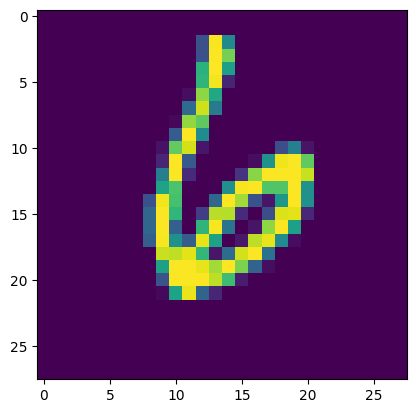

In [21]:
plt.imshow(X_train[0])
print("Label:", y_train[0])

In [22]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))

model.add(Dense(256, activation="relu"))
model.add(Dense(128, activation="relu"))

model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8284 - loss: 0.5922 - val_accuracy: 0.9481 - val_loss: 0.1765
Epoch 2/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9580 - loss: 0.1398 - val_accuracy: 0.9650 - val_loss: 0.1195
Epoch 3/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9743 - loss: 0.0866 - val_accuracy: 0.9701 - val_loss: 0.1074
Epoch 4/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9829 - loss: 0.0535 - val_accuracy: 0.9744 - val_loss: 0.0968
Epoch 5/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9895 - loss: 0.0361 - val_accuracy: 0.9714 - val_loss: 0.1074
Epoch 6/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9921 - loss: 0.0264 - val_accuracy: 0.9705 - val_loss: 0.1170
Epoch 7/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9947 - loss: 0.0176 - val_accuracy: 0.9714 - val_loss: 0.1127
Epoch 8/15
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9960 - loss: 0.0134 - val_accuracy: 0

In [26]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.1321
Test Accuracy: 0.9747619032859802


In [43]:
pred = model.predict(test)
pred_labels = np.argmax(pred, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [44]:
print(len(pred_labels))

28000


In [45]:
print(pred_labels[:20])

[2 0 9 9 3 7 0 3 0 3 5 7 4 0 4 5 3 1 9 0]


In [42]:
print(test.shape)

(28000, 28, 28)


263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


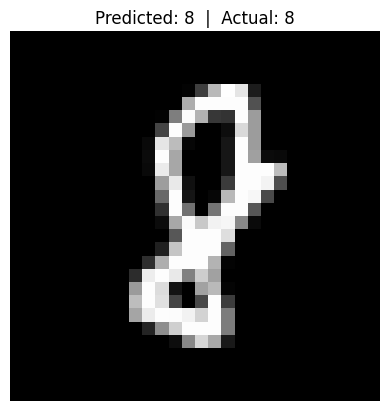

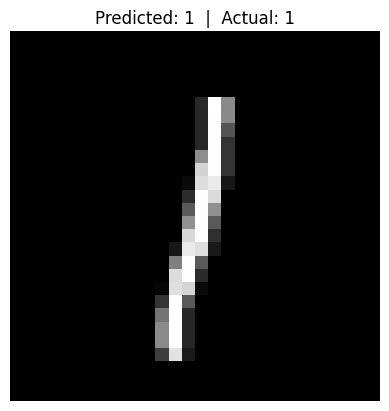

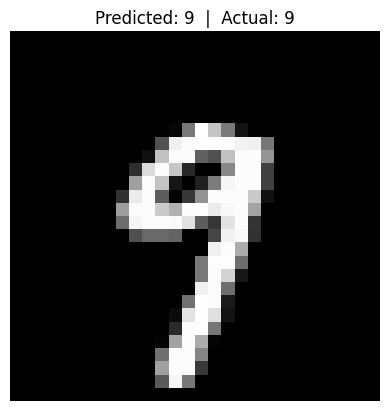

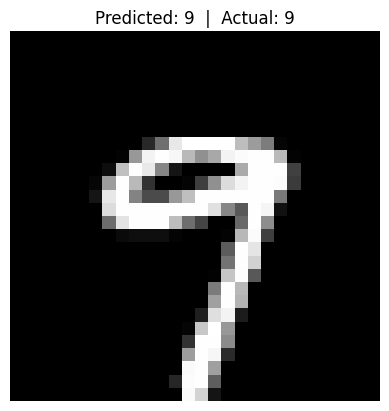

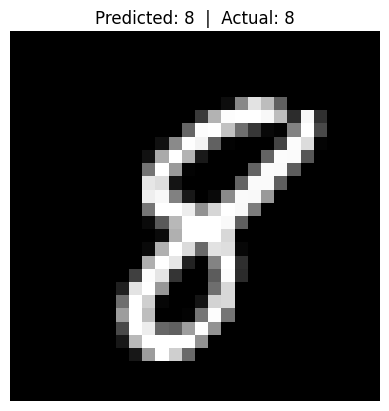

In [46]:
pred = model.predict(X_test)
pred_labels = np.argmax(pred, axis=1)

for i in range(5):
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Predicted: {pred_labels[i]}  |  Actual: {y_test[i]}")
    plt.axis("off")
    plt.show()

In [49]:
print("Test dataset shape:", test.shape)

pred = model.predict(test)

print("Prediction shape:", pred.shape)

Test dataset shape: (28000, 28, 28)
875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Prediction shape: (28000, 10)


In [50]:
pred_labels = np.argmax(pred, axis=1)

print(len(pred_labels))

28000


In [67]:
import pandas as pd

submission = pd.DataFrame({
    "ImageId": range(1, len(pred_labels) + 1),
    "Label": pred_labels
})

print(submission.shape)

(28000, 2)


In [59]:
pred_test = model.predict(X_test)
pred_labels_test = np.argmax(pred_test, axis=1)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


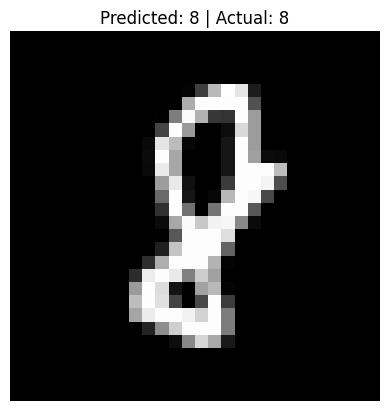

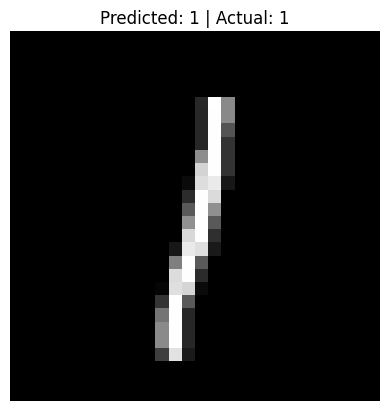

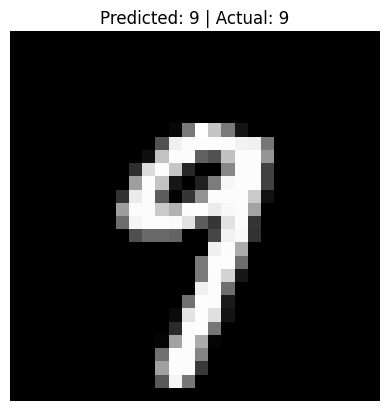

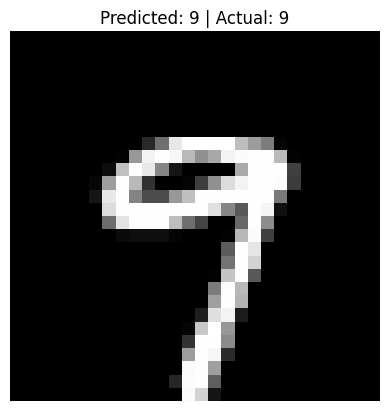

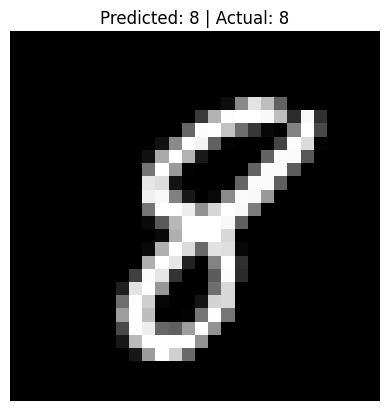

In [60]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Predicted: {pred_labels_test[i]} | Actual: {y_test[i]}")
    plt.axis("off")
    plt.show()

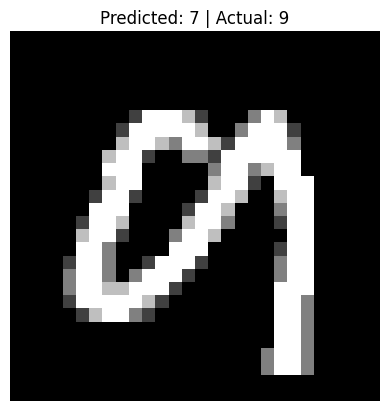

In [61]:
for i in range(len(X_test)):
    if pred_labels_test[i] != y_test[i]:
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Predicted: {pred_labels_test[i]} | Actual: {y_test[i]}")
        plt.axis("off")
        plt.show()
        break

In [62]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred_labels_test))

Accuracy: 0.9747619047619047


In [63]:
submission.to_csv("submission.csv", index=False)

In [64]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [66]:
submission.tail()

,ImageId,Label
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9
27999,28000,2
